# Do NHL Forwards Score More Points Per Game Than Defensemen?

## Research Question

Do NHL forwards have a higher average points per game (PPG) than defensemen during the 2025–26 regular season?

### Hypotheses

- **H₀ (null hypothesis):** Forwards do not have a higher mean PPG than defensemen.
- **H₁ (alternative hypothesis):** Forwards have a higher mean PPG than defensemen.

## Data

This analysis uses NHL skater statistics for the 2025–2026 regular season.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

df = pd.read_csv("../data/skaters_by_season_summary.csv")

df.head()

,assists,evGoals,evPoints,faceoffWinPct,gameWinningGoals,gamesPlayed,goals,lastName,otGoals,penaltyMinutes,...,ppPoints,seasonId,shGoals,shPoints,shootingPct,shootsCatches,shots,skaterFullName,teamAbbrevs,timeOnIcePerGame
0,4,NaN,NaN,NaN,0,32,2,Harris,0,20,...,NaN,19301931,NaN,NaN,NaN,L,NaN,Henry Harris,BOS,NaN
1,0,NaN,NaN,NaN,0,3,0,Spence,0,0,...,NaN,19251926,NaN,NaN,NaN,L,NaN,Gordon Spence,TSP,NaN
2,2,5.0,7.0,NaN,0,32,5,Hudson,0,2,...,0.0,19371938,0.0,0.0,NaN,R,NaN,Ron Hudson,DET,NaN
3,0,0.0,0.0,NaN,0,1,0,Hudson,0,0,...,0.0,19391940,0.0,0.0,NaN,R,NaN,Ron Hudson,DET,NaN
4,3,2.0,5.0,NaN,0,15,2,Johnson,0,8,...,0.0,19571958,0.0,0.0,NaN,L,NaN,Norm Johnson,BOS,NaN


In [2]:
print(df.columns)
print(df["seasonId"].unique())

Index(['assists', 'evGoals', 'evPoints', 'faceoffWinPct', 'gameWinningGoals',
       'gamesPlayed', 'goals', 'lastName', 'otGoals', 'penaltyMinutes',
       'playerId', 'plusMinus', 'points', 'pointsPerGame', 'positionCode',
       'ppGoals', 'ppPoints', 'seasonId', 'shGoals', 'shPoints', 'shootingPct',
       'shootsCatches', 'shots', 'skaterFullName', 'teamAbbrevs',
       'timeOnIcePerGame'],
      dtype='str')
[19301931 19251926 19371938 19391940 19571958 19581959 19521953 19261927
 19271928 19281929 19291930 19311932 19321933 19331934 19661967 19381939
 19401941 19411942 19421943 19451946 19461947 19471948 19481949 19491950
 19501951 19511952 19531954 19561957 19691970 19171918 19181919 19221923
 19231924 19241925 19731974 19741975 19751976 19761977 19771978 19591960
 19601961 19431944 19541955 19671968 19681969 19801981 19861987 19871988
 19891990 19901991 19911992 19921993 19841985 19851986 19881989 19931994
 19941995 19951996 19961997 19971998 19981999 19992000 20002001 1982198

### Data filtering

In [3]:
# create a new DataFrame containing only the 2025-2026 season
df_2526 = df[df["seasonId"] == 20252026].copy()
df_2526.shape

(940, 26)

### Position grouping

In [4]:
# show the counts of each position code in the 2025-2026 season
df_2526["positionCode"].value_counts()


positionCode
D    325
C    298
L    165
R    152
Name: count, dtype: int64

For our analysis, we will group C, L, and R as forwards, and D as defensemen.

In [5]:
df_2526["positionGroup"] = df_2526["positionCode"].map({
    "C": "Forward",
    "L": "Forward",
    "R": "Forward",
    "D": "Defenseman"
})
df_2526["positionGroup"].value_counts()

positionGroup
Forward       615
Defenseman    325
Name: count, dtype: int64

In [6]:
# Check for missing values in the "pointsPerGame" column
df_2526["pointsPerGame"].isna().sum()

np.int64(0)

### Descriptive statistics

In [7]:
print(f"{df_2526['pointsPerGame'].describe()}\n\n{df_2526['gamesPlayed'].describe()}")

count    940.000000
mean       0.376939
std        0.303401
min        0.000000
25%        0.169665
50%        0.297235
75%        0.513085
max        2.000000
Name: pointsPerGame, dtype: float64

count    940.000000
mean      50.244681
std       29.082852
min        1.000000
25%       22.000000
50%       61.000000
75%       77.000000
max       83.000000
Name: gamesPlayed, dtype: float64


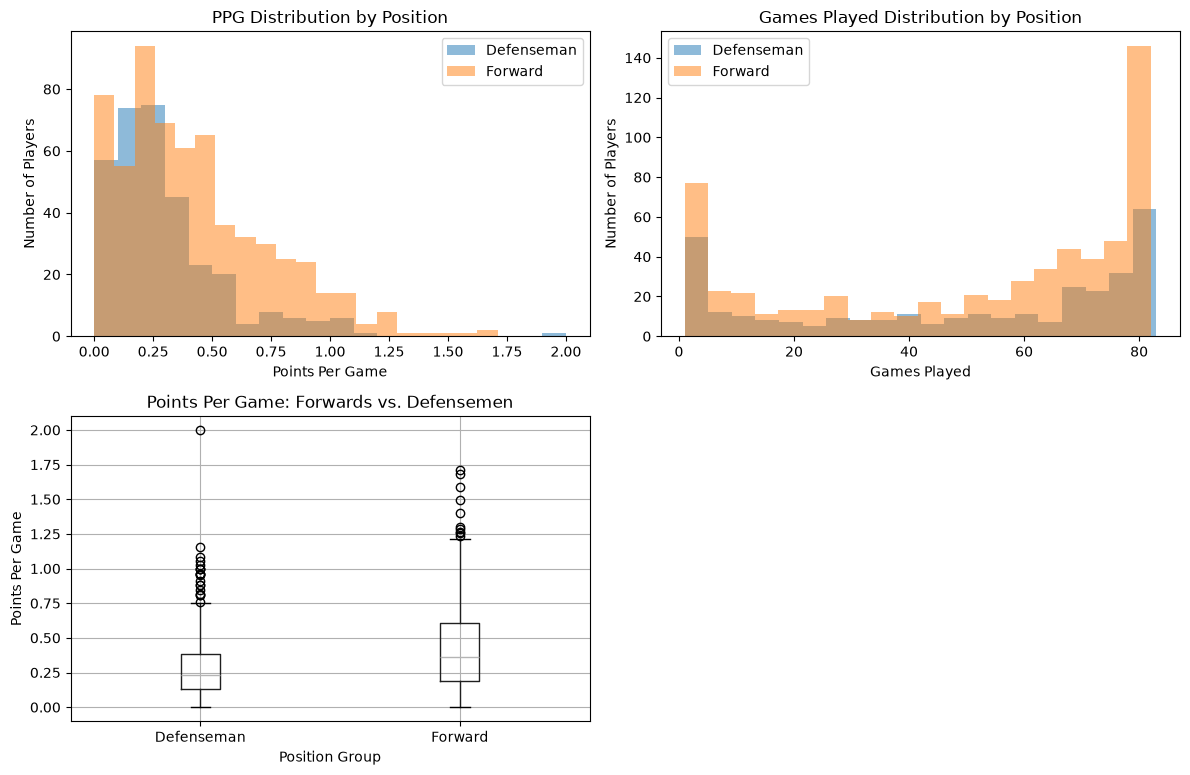

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # turns 2x2 grid into a flat list: axes[0..3]

df_2526.groupby("positionGroup")["pointsPerGame"].plot(
    kind="hist",
    alpha=0.5,
    bins=20,
    legend=True,
    ax=axes[0]
)
axes[0].set_xlabel("Points Per Game")
axes[0].set_ylabel("Number of Players")
axes[0].set_title("PPG Distribution by Position")

df_2526.groupby("positionGroup")["gamesPlayed"].plot(
    kind="hist",
    alpha=0.5,
    bins=20,
    legend=True,
    ax=axes[1]
)
axes[1].set_xlabel("Games Played")
axes[1].set_ylabel("Number of Players")
axes[1].set_title("Games Played Distribution by Position")

df_2526.boxplot(
    column="pointsPerGame",
    by="positionGroup",
    ax=axes[2]
)
axes[2].set_title("Points Per Game: Forwards vs. Defensemen")
axes[2].set_xlabel("Position Group")
axes[2].set_ylabel("Points Per Game")

axes[3].axis("off")  # hide the unused 4th subplot

plt.suptitle("")  # removes pandas' auto-added "Boxplot grouped by..." title
plt.tight_layout()
plt.show()

In [9]:
# check for outliers in the "pointsPerGame" column
df_2526[df_2526["pointsPerGame"] > 1.24]

,assists,evGoals,evPoints,faceoffWinPct,gameWinningGoals,gamesPlayed,goals,lastName,otGoals,penaltyMinutes,...,seasonId,shGoals,shPoints,shootingPct,shootsCatches,shots,skaterFullName,teamAbbrevs,timeOnIcePerGame,positionGroup
40909,86,35.0,92.0,0.00000,8,76,44,Kucherov,2,50,...,20252026,1.0,1.0,0.19047,L,231.0,Nikita Kucherov,TBL,1220.1052,Forward
41008,67,29.0,80.0,0.46661,6,82,36,Scheifele,1,43,...,20252026,0.0,1.0,0.20571,R,175.0,Mark Scheifele,WPG,1290.2439,Forward
42676,74,42.0,97.0,0.51049,7,80,53,MacKinnon,1,39,...,20252026,0.0,0.0,0.15142,R,350.0,Nathan MacKinnon,COL,1335.7125,Forward
43127,62,18.0,54.0,0.56935,3,65,35,Draisaitl,1,26,...,20252026,1.0,1.0,0.18817,L,186.0,Leon Draisaitl,EDM,1294.5076,Forward
43323,71,19.0,67.0,0.22222,4,77,29,Pastrnak,1,72,...,20252026,0.0,0.0,0.11111,R,261.0,David Pastrnak,BOS,1239.3376,Forward
43819,90,34.0,82.0,0.49512,4,82,48,McDavid,1,44,...,20252026,1.0,2.0,0.15686,L,306.0,Connor McDavid,EDM,1379.1219,Forward
45532,62,29.0,76.0,0.42857,5,78,38,Necas,0,30,...,20252026,0.0,0.0,0.18446,R,206.0,Martin Necas,COL,1289.8846,Forward
46516,50,22.0,52.0,0.34772,5,61,27,Hughes,1,10,...,20252026,1.0,2.0,0.11842,L,228.0,Jack Hughes,NJD,1278.9344,Forward
47498,1,1.0,2.0,NaN,0,1,1,Bonk,0,0,...,20252026,0.0,0.0,1.00000,R,1.0,Oliver Bonk,PHI,988.0000,Defenseman
47596,70,37.0,82.0,0.48638,5,82,45,Celebrini,2,44,...,20252026,0.0,0.0,0.15679,L,287.0,Macklin Celebrini,SJS,1278.9512,Forward


In [10]:
# checking for players with very few games played, who might skew PPG
df_2526["gamesPlayed"].value_counts().sort_index().head(20)

gamesPlayed
1     31
2     23
3     34
4     24
5     15
6     10
7      6
8      8
9     11
10     4
11     9
12     8
13    11
14     5
15     7
16     3
17     4
18     5
19     7
20     4
Name: count, dtype: int64

In [11]:
# let's see how much data we would lose with different thresholds
for minimum_games in [1, 5, 10, 15, 20]:
    count = (df_2526["gamesPlayed"] >= minimum_games).sum()
    print(f"{minimum_games}+ games: {count} players ({round(count / len(df_2526) * 100, 2)}% of all players)")

1+ games: 940 players (100.0% of all players)
5+ games: 828 players (88.09% of all players)
10+ games: 778 players (82.77% of all players)
15+ games: 741 players (78.83% of all players)
20+ games: 715 players (76.06% of all players)


We will use 10+ games as a threshold. It removes players with very limited playing time while retaining about 83% of the dataset.

In [12]:
df_10_plus = df_2526[df_2526["gamesPlayed"] >= 10].copy()
df_10_plus["positionGroup"].value_counts()

positionGroup
Forward       515
Defenseman    263
Name: count, dtype: int64

In [13]:
df_10_plus.groupby("positionGroup")["pointsPerGame"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
positionGroup,,,,,,
Defenseman,263,0.315607,0.25000,0.217695,0.0,1.15853
Forward,515,0.470448,0.40625,0.303596,0.0,1.71052


In [14]:
mean_difference = (
    df_10_plus[df_10_plus["positionGroup"] == "Forward"]["pointsPerGame"].mean()
    - df_10_plus[df_10_plus["positionGroup"] == "Defenseman"]["pointsPerGame"].mean()
)

print(f"Mean difference: {mean_difference}")

Mean difference: 0.15484102646830816


Descriptive analysis shows that forwards have a higher average PPG (0.47 vs. 0.32) with mean difference 0.15 PPG.

But a difference in sample means doesn't automatically mean the difference is statistically significant.

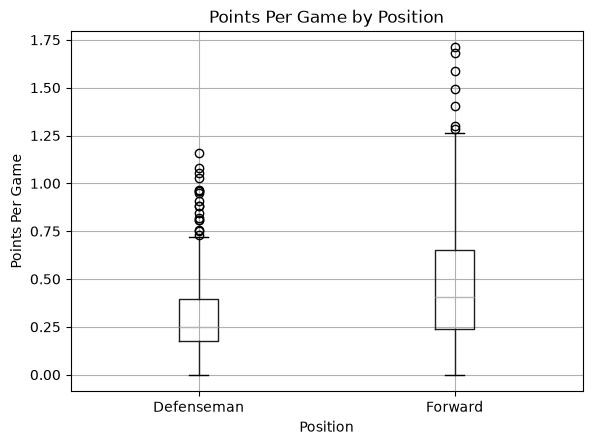

In [15]:
df_10_plus.boxplot(
    column="pointsPerGame",
    by="positionGroup"
)

plt.title("Points Per Game by Position")
plt.suptitle("")
plt.xlabel("Position")
plt.ylabel("Points Per Game")
plt.show()

- The forward distribution is shifted upward relative to defensemen.
- Both groups have high-PPG outliers.
- Forwards also show greater variability, which is consistent with the larger standard deviation we calculated (0.304 vs 0.218).

## Hypothesis test

Now we are ready to test whether that observed difference is statistically significant.

We will use a **one-sided Welch's t-test**, because:

- We have two independent groups.
- We are testing whether forwards have a higher mean.
- The groups have different sample sizes (515 vs. 263).
- Their variances are different.

In [16]:
forwards = df_10_plus[
    df_10_plus["positionGroup"] == "Forward"
]["pointsPerGame"]

defensemen = df_10_plus[
    df_10_plus["positionGroup"] == "Defenseman"
]["pointsPerGame"]

test_result = stats.ttest_ind(
    forwards,
    defensemen,
    equal_var=False,
    alternative="greater"
)

test_result

TtestResult(statistic=np.float64(8.170301032727233), pvalue=np.float64(7.302566365119871e-16), df=np.float64(692.626197685526))

p-value = 7.3 × 10<sup>-16</sup> — essentially zero. The p-value is far below the 0.05 significance level, so we reject the null hypothesis.

## Confidence interval

Now we will calculate the 95% confidence interval for the difference in mean PPG.

In [17]:
mean_diff = forwards.mean() - defensemen.mean()

se = np.sqrt(
    forwards.var(ddof=1) / len(forwards) +
    defensemen.var(ddof=1) / len(defensemen)
)

t_critical = stats.t.ppf(
    0.975,
    df=test_result.df
)

ci_lower = mean_diff - t_critical * se
ci_upper = mean_diff + t_critical * se

print(f"mean difference: {mean_diff}\nlower bound:     {ci_lower}\nupper bound:     {ci_upper}")

mean difference: 0.15484102646830816
lower bound:     0.11763137132469098
upper bound:     0.19205068161192534


With 95% confidence, we estimate that the true difference in mean PPG between forwards and defensemen is between 0.118 and 0.192 points per game.

Also the entire interval is above zero. That is consistent with our hypothesis-test result that forwards have a higher mean PPG.

## Conclusion

The descriptive statistics show that forwards had a higher average points per game (0.47) than defensemen (0.32) during the 2025–26 regular season.

To test whether this difference was statistically significant, a one-sided Welch's t-test was conducted comparing points per game between forwards and defensemen. The results showed a statistically significant difference (p < 0.001), allowing us to reject the null hypothesis.

95% CI: 0.118–0.192 PPG

So the estimated difference is not just statistically significant—it gives us a reasonable range for the size of the difference.

**We conclude that NHL forwards had a significantly higher points-per-game average than defensemen during the 2025–26 regular season**, consistent with forwards' primary offensive role on the ice.